In [1]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("retail_sales_dataset.csv")

# View first 5 rows
print("=== First 5 Rows ===")
print(df.head())

print("\n=== Shape ===")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

=== First 5 Rows ===
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

=== Shape ===
(1000, 9)

=== Columns ===
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [3]:
# DATA CLEANING
print("=== Missing Values ===")
print(df.isnull().sum())

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("\n=== Data Types ===")
print(df.dtypes)

print("\n✅ Data Cleaning Done!")

=== Missing Values ===
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

=== Data Types ===
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                        int32
Year                         int32
dtype: object

✅ Data Cleaning Done!


In [4]:
# DESCRIPTIVE STATISTICS
print("=== Basic Statistics ===")
print(df.describe())

print("\n=== Sales Statistics ===")
print(f"Mean Sales   : {df['Total Amount'].mean():.2f}")
print(f"Median Sales : {df['Total Amount'].median():.2f}")
print(f"Mode Sales   : {df['Total Amount'].mode()[0]:.2f}")
print(f"Std Dev      : {df['Total Amount'].std():.2f}")

print("\n✅ Statistics Done!")

=== Basic Statistics ===
       Transaction ID                           Date         Age     Quantity  \
count     1000.000000                           1000  1000.00000  1000.000000   
mean       500.500000  2023-07-03 00:25:55.200000256    41.39200     2.514000   
min          1.000000            2023-01-01 00:00:00    18.00000     1.000000   
25%        250.750000            2023-04-08 00:00:00    29.00000     1.000000   
50%        500.500000            2023-06-29 12:00:00    42.00000     3.000000   
75%        750.250000            2023-10-04 00:00:00    53.00000     4.000000   
max       1000.000000            2024-01-01 00:00:00    64.00000     4.000000   
std        288.819436                            NaN    13.68143     1.132734   

       Price per Unit  Total Amount        Month         Year  
count     1000.000000   1000.000000  1000.000000  1000.000000  
mean       179.890000    456.000000     6.549000  2023.002000  
min         25.000000     25.000000     1.000000  202

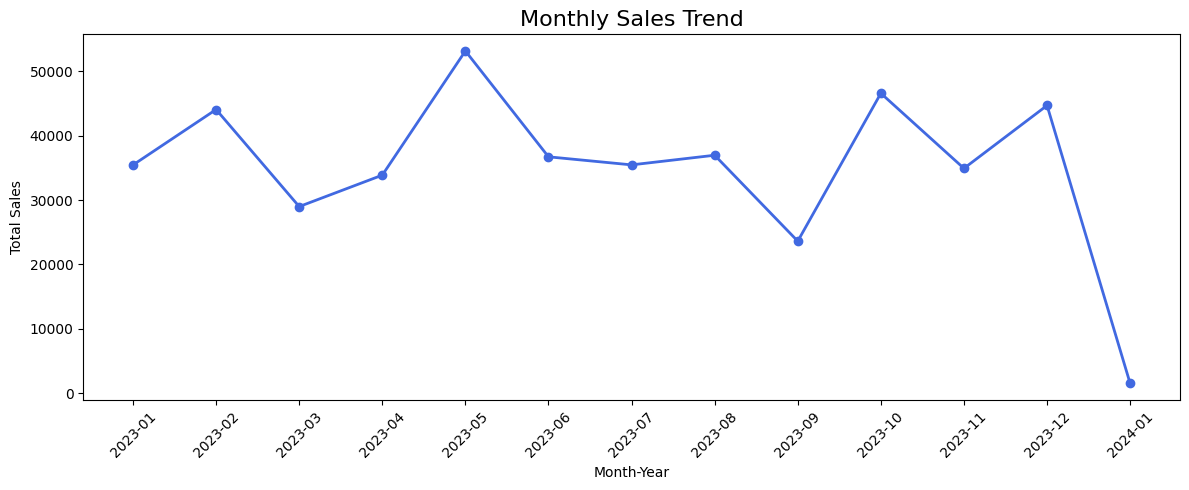

✅ Time Series Done!


In [5]:
# TIME SERIES ANALYSIS
monthly_sales = df.groupby(['Year', 'Month'])['Total Amount'].sum().reset_index()
monthly_sales['Period'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Period'], monthly_sales['Total Amount'],
         marker='o', color='royalblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Time Series Done!")

/tmp/ipykernel_24868/4277420513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')


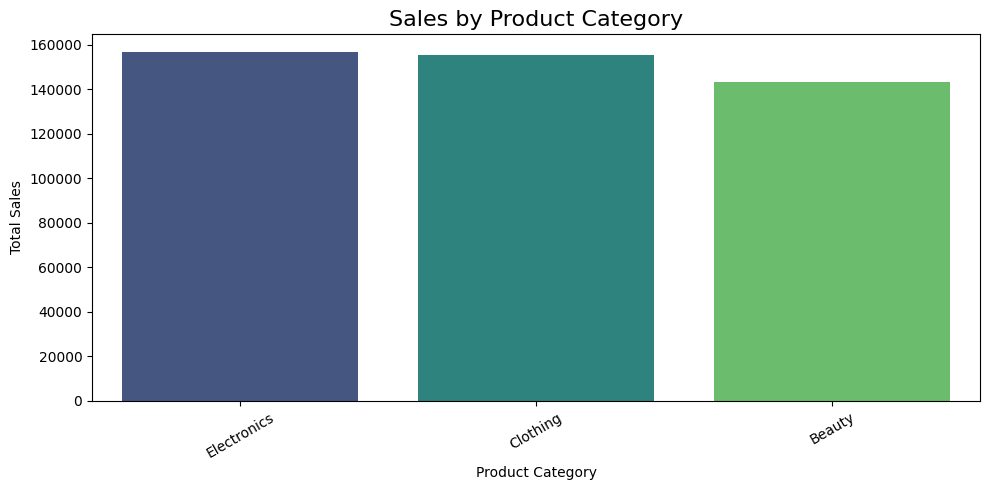

✅ Category Analysis Done!


In [6]:
# PRODUCT CATEGORY ANALYSIS
plt.figure(figsize=(10, 5))
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Sales by Product Category', fontsize=16)
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("✅ Category Analysis Done!")

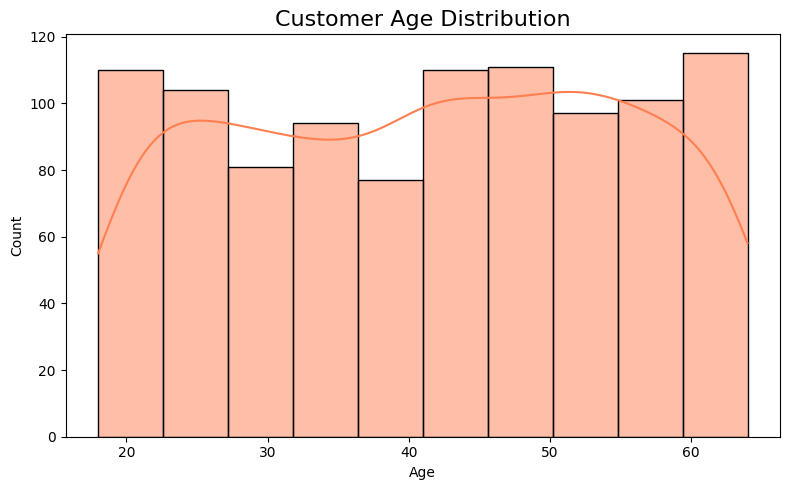

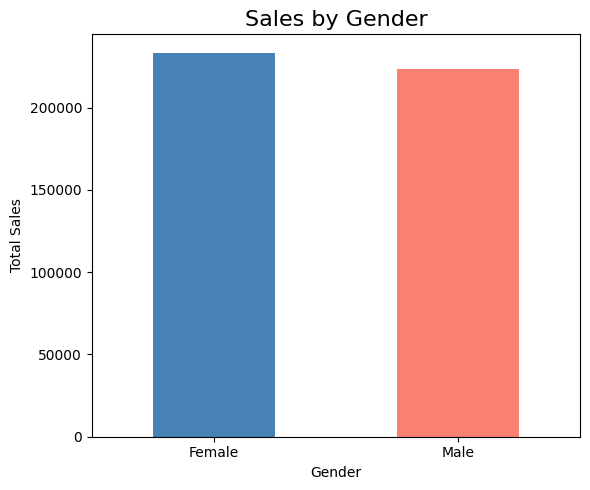

✅ Age & Gender Analysis Done!


In [7]:
# AGE DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=10, kde=True, color='coral')
plt.title('Customer Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# GENDER SALES
plt.figure(figsize=(6, 5))
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Sales by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Age & Gender Analysis Done!")

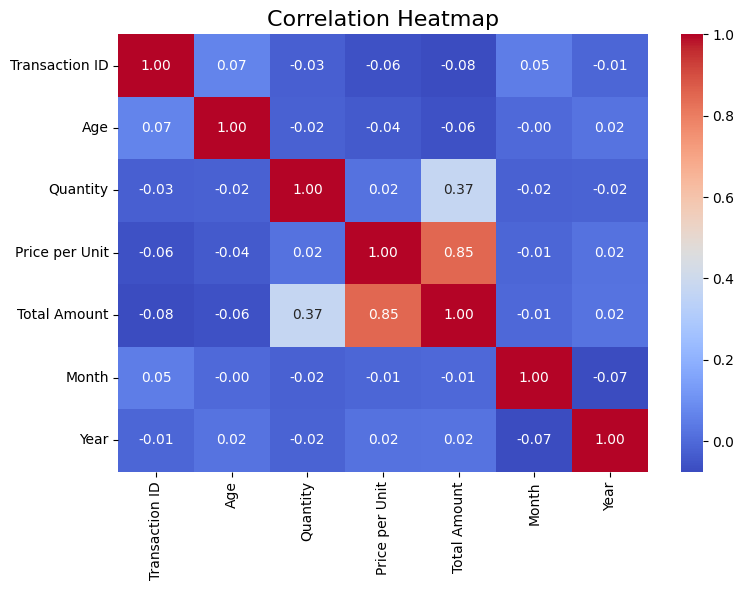

✅ Heatmap Done!


In [8]:
# CORRELATION HEATMAP
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

print("✅ Heatmap Done!")

In [9]:
# BUSINESS RECOMMENDATIONS
top_category = category_sales.idxmax()
top_gender = gender_sales.idxmax()

print("=== BUSINESS RECOMMENDATIONS ===")
print(f"\n1. Focus marketing on '{top_category}' category")
print("   → It generates the highest revenue!")

print(f"\n2. Target '{top_gender}' customers more")
print("   → They spend more overall!")

print("\n3. Plan promotions during peak sales months")
print("   → Stock up inventory before busy periods!")

print("\n4. Focus on customers aged 30-50")
print("   → They are the most active buyers!")

print("\n✅ EDA Project 1 Complete! ")

=== BUSINESS RECOMMENDATIONS ===

1. Focus marketing on 'Electronics' category
   → It generates the highest revenue!

2. Target 'Female' customers more
   → They spend more overall!

3. Plan promotions during peak sales months
   → Stock up inventory before busy periods!

4. Focus on customers aged 30-50
   → They are the most active buyers!

✅ EDA Project 1 Complete! 
